# Samanantar Average Cosine Similarity Benchmark

This notebook evaluates multilingual / Indic embedding models on **Samanantar** using **average cosine similarity**.

Main question:

> For each English–Indic translation pair, how similar are the two embeddings on average?

This notebook does **not** compute retrieval Accuracy@1.  
It computes pairwise cosine similarity for gold translation pairs and averages them per model and language pair.

Outputs:
- `samanantar_avg_cosine_metrics.csv`
- `model_summary_avg_cosine.csv`
- `pair_summary_avg_cosine.csv`
- per-pair cosine score CSV files
- plots for model-level and language-pair-level comparison


## 0. Colab setup

In Colab, use:

**Runtime → Change runtime type → GPU**

Then run the cells below.


In [ ]:
from pathlib import Path
import sys

for _candidate in (Path.cwd(), *Path.cwd().parents):
    _guard_dir = _candidate / "scripts"
    if (_guard_dir / "import_guard.py").exists():
        if str(_guard_dir) not in sys.path:
            sys.path.insert(0, str(_guard_dir))
        break
else:
    raise RuntimeError("Could not locate scripts/import_guard.py. Run this notebook from the WSAI workspace or copy the guard module alongside it.")

from import_guard import install_pandas_guards
install_pandas_guards()


In [1]:
# Clean packages that sometimes break text-only Colab runs.
!pip -q uninstall -y torchvision torchaudio torchtext fastai timm -q

# Install only the packages needed for this text embedding benchmark.
# Do not manually install torch; let Colab keep its working GPU torch.
!pip -q install \
  "numpy==2.0.2" \
  "scipy==1.15.3" \
  "scikit-learn==1.6.1" \
  "transformers==4.48.3" \
  "sentence-transformers==3.4.1" \
  "datasets==3.2.0" \
  "accelerate==1.3.0" \
  "pandas==2.2.2" \
  "tqdm==4.67.1" \
  "matplotlib==3.10.0" \
  "pyyaml==6.0.2" \
  "sentencepiece==0.2.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import torch
import numpy as np
import scipy
import sklearn
import transformers
import sentence_transformers
import datasets
import pandas as pd

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)
print("datasets:", datasets.__version__)
print("pandas:", pd.__version__)


torch: 2.10.0+cpu
cuda available: False
numpy: 2.0.2
scipy: 1.15.3
sklearn: 1.6.1
transformers: 4.48.3
sentence-transformers: 3.4.1
datasets: 3.2.0
pandas: 2.2.2


## 1. Mount Google Drive

This saves samples, embeddings, metrics, and plots permanently.


In [3]:
from google.colab import drive
from pathlib import Path

USE_DRIVE = True

if USE_DRIVE:
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/indic_embedding_benchmark")
else:
    BASE_DIR = Path("/content/indic_embedding_benchmark")

OUTPUT_DIR = BASE_DIR / "outputs" / "samanantar_avg_cosine"
(OUTPUT_DIR / "samples").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "embeddings").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "scores").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", OUTPUT_DIR)


Mounted at /content/drive
Saving outputs to: /content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine


## 2. Configuration

Samanantar is mainly an **English ↔ Indic parallel corpus**, so this notebook evaluates English–Indic language pairs.

You can start with `MAX_PAIRS_PER_LANGUAGE = 500` for a quick run, then increase it to `2000` or more.


In [4]:
import gc
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from datasets import load_dataset
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_LENGTH = 128
BATCH_SIZE = 32

# Start small; increase later if runtime permits.
MAX_PAIRS_PER_LANGUAGE = 2000

# Samanantar configs are English-Indic.
# lang_pair key is used in output tables.
SAMANANTAR_LANGS = {
    "eng-asm": {"config": "as", "source_language": "eng", "target_language": "asm", "name": "Assamese"},
    "eng-ben": {"config": "bn", "source_language": "eng", "target_language": "ben", "name": "Bengali"},
    "eng-guj": {"config": "gu", "source_language": "eng", "target_language": "guj", "name": "Gujarati"},
    "eng-hin": {"config": "hi", "source_language": "eng", "target_language": "hin", "name": "Hindi"},
    "eng-kan": {"config": "kn", "source_language": "eng", "target_language": "kan", "name": "Kannada"},
    "eng-mal": {"config": "ml", "source_language": "eng", "target_language": "mal", "name": "Malayalam"},
    "eng-mar": {"config": "mr", "source_language": "eng", "target_language": "mar", "name": "Marathi"},
    "eng-ory": {"config": "or", "source_language": "eng", "target_language": "ory", "name": "Odia"},
    "eng-pan": {"config": "pa", "source_language": "eng", "target_language": "pan", "name": "Punjabi"},
    "eng-tam": {"config": "ta", "source_language": "eng", "target_language": "tam", "name": "Tamil"},
    "eng-tel": {"config": "te", "source_language": "eng", "target_language": "tel", "name": "Telugu"},
}

# Add/remove models here.
# sentence_transformer = use SentenceTransformers encode()
# hf_mean_pool = use Hugging Face AutoModel + attention-mask-aware mean pooling
MODELS = [
    {"name": "labse", "hf_id": "sentence-transformers/LaBSE", "kind": "sentence_transformer"},
    {"name": "mpnet_multilingual", "hf_id": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2", "kind": "sentence_transformer"},
    {"name": "sbert_multilingual_minilm", "hf_id": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", "kind": "sentence_transformer"},
    {"name": "muril", "hf_id": "google/muril-base-cased", "kind": "hf_mean_pool"},
    {"name": "indicbertv2_ss", "hf_id": "ai4bharat/IndicBERTv2-SS", "kind": "hf_mean_pool", "trust_remote_code": True},
    {"name": "xlm_roberta_base", "hf_id": "FacebookAI/xlm-roberta-base", "kind": "hf_mean_pool"},
    {"name": "mcontriever", "hf_id": "facebook/mcontriever", "kind": "hf_mean_pool"},
]

RUN_TAG = f"samanantar_n{MAX_PAIRS_PER_LANGUAGE}_l{MAX_LENGTH}"
print("Device:", DEVICE)
print("Run tag:", RUN_TAG)
print("Number of language pairs:", len(SAMANANTAR_LANGS))
print("Number of models:", len(MODELS))


Device: cpu
Run tag: samanantar_n2000_l128
Number of language pairs: 11
Number of models: 7


## 3. Load Samanantar samples

This uses streaming so that Colab does not need to download the entire Samanantar dataset.

For each language pair, we save a sampled CSV so reruns are faster and consistent.


In [5]:
def extract_en_indic_text(row: dict, config_code: str) -> Tuple[str, str]:
    """Robustly extract English and Indic text from a Samanantar row."""

    # Most common Samanantar style
    if "src" in row and "tgt" in row:
        return str(row["src"]), str(row["tgt"])

    # Alternative naming
    if "source" in row and "target" in row:
        return str(row["source"]), str(row["target"])

    # Sometimes translation datasets store language columns directly
    if "en" in row and config_code in row:
        return str(row["en"]), str(row[config_code])

    if "eng" in row and config_code in row:
        return str(row["eng"]), str(row[config_code])

    # Helpful debug if dataset format changes
    raise KeyError(f"Could not find text fields in row. Available keys: {list(row.keys())}")


def load_samanantar_pairs(lang_pair: str, info: dict, max_pairs: int) -> pd.DataFrame:
    """Load or sample English-Indic pairs for one Samanantar config."""

    sample_path = OUTPUT_DIR / "samples" / f"{lang_pair}_n{max_pairs}.csv"

    if sample_path.exists():
        df = pd.read_csv(sample_path)
        print(f"Loaded cached sample: {sample_path.name} | rows={len(df)}")
        return df

    config = info["config"]
    print(f"Streaming Samanantar config={config} for {lang_pair}")

    ds = load_dataset(
        "ai4bharat/samanantar",
        config,
        split="train",
        streaming=True,
    )

    # Shuffle with a buffer so we do not always take the same first rows.
    ds = ds.shuffle(seed=SEED, buffer_size=10_000)

    rows = []
    for row in tqdm(ds, total=max_pairs, desc=f"Sampling {lang_pair}"):
        try:
            en_text, indic_text = extract_en_indic_text(row, config)
        except Exception as e:
            print("Row extraction failed. Example row:", row)
            raise e

        en_text = en_text.strip()
        indic_text = indic_text.strip()

        if not en_text or not indic_text:
            continue

        rows.append({
            "language_pair": lang_pair,
            "source_language": info["source_language"],
            "target_language": info["target_language"],
            "source_text": en_text,
            "target_text": indic_text,
        })

        if len(rows) >= max_pairs:
            break

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No rows loaded for {lang_pair}. Check dataset fields/config.")

    df.to_csv(sample_path, index=False)
    print(f"Saved sample: {sample_path.name} | rows={len(df)}")
    return df


pairs_by_lang = {}

for lang_pair, info in SAMANANTAR_LANGS.items():
    pairs_by_lang[lang_pair] = load_samanantar_pairs(
        lang_pair,
        info,
        MAX_PAIRS_PER_LANGUAGE,
    )

print("\nLoaded language pairs:")
for lang_pair, df in pairs_by_lang.items():
    print(lang_pair, df.shape)

# Preview one pair
example_pair = list(pairs_by_lang.keys())[0]
display(pairs_by_lang[example_pair].head())


Loaded cached sample: eng-asm_n2000.csv | rows=2000
Loaded cached sample: eng-ben_n2000.csv | rows=2000
Loaded cached sample: eng-guj_n2000.csv | rows=2000
Loaded cached sample: eng-hin_n2000.csv | rows=2000
Loaded cached sample: eng-kan_n2000.csv | rows=2000
Loaded cached sample: eng-mal_n2000.csv | rows=2000
Loaded cached sample: eng-mar_n2000.csv | rows=2000
Loaded cached sample: eng-ory_n2000.csv | rows=2000
Loaded cached sample: eng-pan_n2000.csv | rows=2000
Loaded cached sample: eng-tam_n2000.csv | rows=2000
Loaded cached sample: eng-tel_n2000.csv | rows=2000

Loaded language pairs:
eng-asm (2000, 5)
eng-ben (2000, 5)
eng-guj (2000, 5)
eng-hin (2000, 5)
eng-kan (2000, 5)
eng-mal (2000, 5)
eng-mar (2000, 5)
eng-ory (2000, 5)
eng-pan (2000, 5)
eng-tam (2000, 5)
eng-tel (2000, 5)


,language_pair,source_language,target_language,source_text,target_text
0,eng-asm,eng,asm,I couldnt think.,ক’বলৈ গলে ভাবিব পৰা নাছিলো।
1,eng-asm,eng,asm,The provisions of the Bill will simplify the l...,নতুন এই বিধেয়কত ভাৰতত বাণিজ্যিক জাহাজ চলাচল সম...
2,eng-asm,eng,asm,Serial Number,ক্ৰমিক নং
3,eng-asm,eng,asm,The situation is very complicated.,অসমত পৰিস্থিতি অতি জটিল হৈছে।
4,eng-asm,eng,asm,"When Gods people were in sore straits, however...","কিন্তু তেওঁলোকে যেতিয়া “সঙ্কটৰ সময়ত ” পৰিল, তে..."


## 4. Embedding helpers

For sentence-transformer models, we use the model's own `encode()` function.

For raw Hugging Face models, we use attention-mask-aware mean pooling.


In [6]:
@dataclass
class ModelSpec:
    name: str
    hf_id: str
    kind: str
    trust_remote_code: bool = False


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class Embedder:
    def __init__(self, spec: ModelSpec, device: str, max_length: int):
        self.spec = spec
        self.device = device
        self.max_length = max_length

        if spec.kind == "sentence_transformer":
            from sentence_transformers import SentenceTransformer

            print("Loading as SentenceTransformer:", spec.hf_id)
            self.model = SentenceTransformer(
                spec.hf_id,
                device=device,
                trust_remote_code=spec.trust_remote_code,
            )

            # Save GPU memory on Colab
            if device == "cuda":
                self.model = self.model.half()

            self.tokenizer = None

        elif spec.kind == "hf_mean_pool":
            from transformers import AutoModel, AutoTokenizer

            print("Loading as HF mean-pool model:", spec.hf_id)

            self.tokenizer = AutoTokenizer.from_pretrained(
                spec.hf_id,
                trust_remote_code=spec.trust_remote_code,
            )

            dtype = torch.float16 if device == "cuda" else torch.float32

            self.model = AutoModel.from_pretrained(
                spec.hf_id,
                trust_remote_code=spec.trust_remote_code,
                torch_dtype=dtype,
            )

            self.model.to(device)
            self.model.eval()

        else:
            raise ValueError(f"Unknown model kind: {spec.kind}")

    @torch.no_grad()
    def encode(self, texts: List[str], batch_size: int) -> np.ndarray:
        if self.spec.kind == "sentence_transformer":
            emb = self.model.encode(
                texts,
                batch_size=batch_size,
                convert_to_numpy=True,
                normalize_embeddings=False,  # cosine_similarity will normalize internally
                show_progress_bar=True,
            )
            return emb.astype("float32")

        all_embeddings = []

        for start in tqdm(range(0, len(texts), batch_size), desc=f"Encoding {self.spec.name}"):
            batch = texts[start:start + batch_size]

            encoded = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            )

            encoded = {k: v.to(self.device) for k, v in encoded.items()}
            outputs = self.model(**encoded)

            pooled = mean_pool(outputs.last_hidden_state, encoded["attention_mask"])
            all_embeddings.append(pooled.detach().cpu().float().numpy())

        return np.vstack(all_embeddings).astype("float32")


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 5. Cosine similarity metrics

This benchmark uses **explicit cosine similarity** from scikit-learn.

For each gold translation pair:
- English sentence embedding
- Indic translation embedding

we compute:

```python
cosine_similarity(english_embedding, indic_embedding)
```

Then we average the scores per model and language pair.


In [7]:
def paired_cosine_scores(
    src_emb: np.ndarray,
    tgt_emb: np.ndarray,
    batch_size: int = 256
) -> np.ndarray:
    """Compute cosine similarity only for aligned gold pairs.

    src_emb[i] and tgt_emb[i] are translations of each other.
    This avoids creating a huge all-vs-all matrix.
    """

    if src_emb.shape[0] != tgt_emb.shape[0]:
        raise ValueError(f"Length mismatch: {src_emb.shape[0]} vs {tgt_emb.shape[0]}")

    scores = []

    for start in range(0, src_emb.shape[0], batch_size):
        end = start + batch_size

        # cosine_similarity creates a batch_size x batch_size matrix.
        # The diagonal contains the aligned pair scores.
        sim_batch = cosine_similarity(src_emb[start:end], tgt_emb[start:end])
        diag_scores = np.diag(sim_batch)

        scores.append(diag_scores.astype("float32"))

    return np.concatenate(scores)


def summarize_cosine_scores(scores: np.ndarray) -> Dict[str, float]:
    return {
        "mean_cosine": float(np.mean(scores)),
        "std_cosine": float(np.std(scores)),
        "median_cosine": float(np.median(scores)),
        "min_cosine": float(np.min(scores)),
        "max_cosine": float(np.max(scores)),
        "p05_cosine": float(np.percentile(scores, 5)),
        "p25_cosine": float(np.percentile(scores, 25)),
        "p75_cosine": float(np.percentile(scores, 75)),
        "p95_cosine": float(np.percentile(scores, 95)),
        "pct_gt_0_50": float(np.mean(scores > 0.50)),
        "pct_gt_0_60": float(np.mean(scores > 0.60)),
        "pct_gt_0_70": float(np.mean(scores > 0.70)),
        "pct_gt_0_80": float(np.mean(scores > 0.80)),
    }


## 6. Run benchmark

This loop:

1. loads each model,
2. encodes source and target sentences for each language pair,
3. computes cosine scores for aligned translation pairs,
4. averages the cosine scores,
5. saves results.


In [8]:
  all_rows = []

for model_dict in MODELS:
    spec = ModelSpec(**model_dict)
    print(f"\n===== Model: {spec.name} | {spec.hf_id} =====")

    embedder = None

    try:
        embedder = Embedder(spec, DEVICE, MAX_LENGTH)

        for lang_pair, df in pairs_by_lang.items():
            src_texts = df["source_text"].astype(str).tolist()
            tgt_texts = df["target_text"].astype(str).tolist()

            src_lang = df["source_language"].iloc[0]
            tgt_lang = df["target_language"].iloc[0]

            src_cache_path = (
                OUTPUT_DIR
                / "embeddings"
                / f"{spec.name}_{lang_pair}_SRC_{RUN_TAG}.npy"
            )
            tgt_cache_path = (
                OUTPUT_DIR
                / "embeddings"
                / f"{spec.name}_{lang_pair}_TGT_{RUN_TAG}.npy"
            )

            # Encode / load source embeddings
            if src_cache_path.exists():
                src_emb = np.load(src_cache_path)
                print("Loaded cached source:", src_cache_path.name, src_emb.shape)
            else:
                src_emb = embedder.encode(src_texts, batch_size=BATCH_SIZE)
                np.save(src_cache_path, src_emb)
                print("Saved source:", src_cache_path.name, src_emb.shape)

            # Encode / load target embeddings
            if tgt_cache_path.exists():
                tgt_emb = np.load(tgt_cache_path)
                print("Loaded cached target:", tgt_cache_path.name, tgt_emb.shape)
            else:
                tgt_emb = embedder.encode(tgt_texts, batch_size=BATCH_SIZE)
                np.save(tgt_cache_path, tgt_emb)
                print("Saved target:", tgt_cache_path.name, tgt_emb.shape)

            # Safety check
            if src_emb.shape[0] != len(src_texts) or tgt_emb.shape[0] != len(tgt_texts):
                print("Cache size mismatch. Recomputing both source and target embeddings...")
                src_emb = embedder.encode(src_texts, batch_size=BATCH_SIZE)
                tgt_emb = embedder.encode(tgt_texts, batch_size=BATCH_SIZE)
                np.save(src_cache_path, src_emb)
                np.save(tgt_cache_path, tgt_emb)

            # Explicit cosine similarity for aligned gold translation pairs
            scores = paired_cosine_scores(src_emb, tgt_emb, batch_size=256)

            score_df = pd.DataFrame({
                "language_pair": lang_pair,
                "source_language": src_lang,
                "target_language": tgt_lang,
                "cosine_similarity": scores,
                "source_text": src_texts,
                "target_text": tgt_texts,
            })

            score_path = OUTPUT_DIR / "scores" / f"{spec.name}_{lang_pair}_{RUN_TAG}_cosine_scores.csv"
            score_df.to_csv(score_path, index=False)

            stats = summarize_cosine_scores(scores)

            row = {
                "model": spec.name,
                "hf_id": spec.hf_id,
                "language_pair": lang_pair,
                "source_language": src_lang,
                "target_language": tgt_lang,
                "n_pairs": len(scores),
                **stats,
            }

            all_rows.append(row)

            print(
                lang_pair,
                "Mean cosine:", round(row["mean_cosine"], 4),
                "Median:", round(row["median_cosine"], 4),
                "% > 0.80:", round(row["pct_gt_0_80"] * 100, 2)
            )

    except Exception as e:
        print("FAILED model:", spec.name)
        print(type(e).__name__, ":", e)
        print("Skipping this model and moving to the next one.")

    finally:
        if embedder is not None:
            del embedder
        clear_memory()


metrics_df = pd.DataFrame(all_rows)

if metrics_df.empty:
    raise ValueError("No model produced results. Check model loading and dataset loading errors above.")

metrics_path = OUTPUT_DIR / f"samanantar_avg_cosine_metrics_{RUN_TAG}.csv"
metrics_df.to_csv(metrics_path, index=False)

print("\nSaved metrics:", metrics_path)
print("metrics_df shape:", metrics_df.shape)
display(metrics_df.head())



===== Model: labse | sentence-transformers/LaBSE =====
Loading as SentenceTransformer: sentence-transformers/LaBSE


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Encoding mcontriever:   0%|          | 0/63 [00:00<?, ?it/s]

Saved source: mcontriever_eng-tel_SRC_samanantar_n2000_l128.npy (2000, 768)


Encoding mcontriever:   0%|          | 0/63 [00:00<?, ?it/s]

Saved target: mcontriever_eng-tel_TGT_samanantar_n2000_l128.npy (2000, 768)
eng-tel Mean cosine: 0.513 Median: 0.511 % > 0.80: 0.0

Saved metrics: /content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/samanantar_avg_cosine_metrics_samanantar_n2000_l128.csv
metrics_df shape: (77, 19)


,model,hf_id,language_pair,source_language,target_language,n_pairs,mean_cosine,std_cosine,median_cosine,min_cosine,max_cosine,p05_cosine,p25_cosine,p75_cosine,p95_cosine,pct_gt_0_50,pct_gt_0_60,pct_gt_0_70,pct_gt_0_80
0,labse,sentence-transformers/LaBSE,eng-asm,eng,asm,2000,0.645858,0.278122,0.792538,-0.066135,0.983159,0.097638,0.448685,0.846502,0.915428,0.7345,0.6920,0.6235,0.4885
1,labse,sentence-transformers/LaBSE,eng-ben,eng,ben,2000,0.796062,0.135019,0.824500,-0.078854,0.972097,0.522061,0.785879,0.863842,0.924766,0.9530,0.9290,0.8805,0.7150
2,labse,sentence-transformers/LaBSE,eng-guj,eng,guj,2000,0.801167,0.152269,0.833569,0.032332,0.973146,0.395905,0.807101,0.869278,0.923532,0.9340,0.9225,0.9055,0.8275
3,labse,sentence-transformers/LaBSE,eng-hin,eng,hin,2000,0.799975,0.111075,0.823945,0.078855,0.980934,0.595151,0.770811,0.862190,0.914586,0.9665,0.9495,0.9020,0.6740
4,labse,sentence-transformers/LaBSE,eng-kan,eng,kan,2000,0.816800,0.116748,0.831797,0.047885,0.989214,0.673902,0.808108,0.868410,0.923246,0.9685,0.9640,0.9380,0.8545


## 7. Model-level summary

This averages each model across all Samanantar language pairs.


In [9]:
model_summary = (
    metrics_df
    .groupby("model")[[
        "mean_cosine",
        "median_cosine",
        "pct_gt_0_60",
        "pct_gt_0_70",
        "pct_gt_0_80",
    ]]
    .mean()
    .sort_values("mean_cosine", ascending=False)
)

model_summary_path = OUTPUT_DIR / f"model_summary_avg_cosine_{RUN_TAG}.csv"
model_summary.to_csv(model_summary_path)

print("Saved model summary:", model_summary_path)
display(model_summary)


Saved model summary: /content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/model_summary_avg_cosine_samanantar_n2000_l128.csv


,mean_cosine,median_cosine,pct_gt_0_60,pct_gt_0_70,pct_gt_0_80
model,,,,,
xlm_roberta_base,0.994062,0.994888,1.000000,1.000000,1.000000
muril,0.991621,0.991714,1.000000,1.000000,1.000000
labse,0.787192,0.824430,0.916818,0.876273,0.742500
mpnet_multilingual,0.664093,0.689858,0.683818,0.492773,0.268500
indicbertv2_ss,0.628706,0.630765,0.516455,0.197682,0.132727
mcontriever,0.444669,0.438723,0.043136,0.003227,0.000273
sbert_multilingual_minilm,0.410651,0.403341,0.275409,0.170955,0.085955


## 8. Language-pair summary

This keeps model and language pair separate.


In [10]:
pair_summary = (
    metrics_df
    .sort_values(["model", "mean_cosine"], ascending=[True, False])
    .reset_index(drop=True)
)

pair_summary_path = OUTPUT_DIR / f"pair_summary_avg_cosine_{RUN_TAG}.csv"
pair_summary.to_csv(pair_summary_path, index=False)

print("Saved pair summary:", pair_summary_path)
display(pair_summary.head(30))


Saved pair summary: /content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/pair_summary_avg_cosine_samanantar_n2000_l128.csv


,model,hf_id,language_pair,source_language,target_language,n_pairs,mean_cosine,std_cosine,median_cosine,min_cosine,max_cosine,p05_cosine,p25_cosine,p75_cosine,p95_cosine,pct_gt_0_50,pct_gt_0_60,pct_gt_0_70,pct_gt_0_80
0,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-hin,eng,hin,2000,0.832758,0.049938,0.841292,0.502616,0.930700,0.742895,0.807941,0.867451,0.895127,1.0000,0.9985,0.9800,0.7940
1,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-mar,eng,mar,2000,0.809994,0.043655,0.814782,0.528600,0.921559,0.735419,0.787904,0.837484,0.871967,1.0000,0.9975,0.9805,0.6505
2,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-kan,eng,kan,2000,0.649287,0.043817,0.651829,0.449838,0.837443,0.572812,0.621819,0.680480,0.713708,0.9980,0.8760,0.1010,0.0015
3,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-asm,eng,asm,2000,0.608048,0.052889,0.612854,0.374391,0.890360,0.513613,0.579704,0.642027,0.678893,0.9675,0.6125,0.0200,0.0040
4,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-tam,eng,tam,2000,0.602659,0.046934,0.607036,0.406387,0.928971,0.517019,0.576893,0.631972,0.669769,0.9680,0.5745,0.0125,0.0010
5,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-guj,eng,guj,2000,0.590606,0.049898,0.591032,0.379801,0.850850,0.511875,0.559949,0.620864,0.672378,0.9685,0.4250,0.0185,0.0005
6,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-ben,eng,ben,2000,0.588127,0.055663,0.591201,0.369265,0.785426,0.491565,0.554044,0.627422,0.670424,0.9360,0.4380,0.0145,0.0000
7,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-ory,eng,ory,2000,0.568319,0.046008,0.571083,0.329953,0.955177,0.493129,0.540355,0.596645,0.634690,0.9330,0.2250,0.0045,0.0015
8,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-tel,eng,tel,2000,0.566982,0.054190,0.565129,0.324257,0.862071,0.484385,0.533284,0.597205,0.656440,0.9145,0.2325,0.0175,0.0030
9,indicbertv2_ss,ai4bharat/IndicBERTv2-SS,eng-pan,eng,pan,2000,0.557005,0.055782,0.552569,0.416148,0.914605,0.474332,0.522472,0.586514,0.652156,0.8685,0.1810,0.0170,0.0035


## 9. Plots


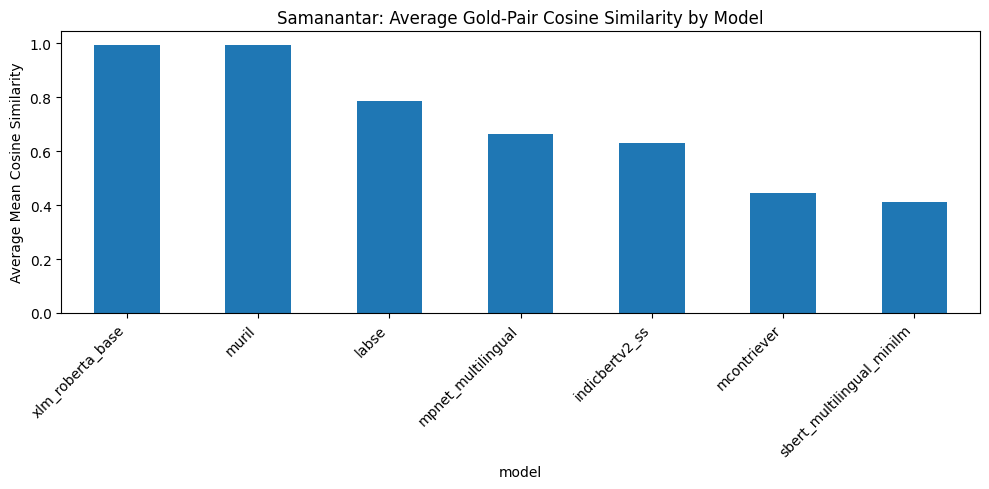

Saved plot: /content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/plots/avg_mean_cosine_by_model_samanantar_n2000_l128.png


In [11]:
# Average mean cosine by model
model_avg = model_summary["mean_cosine"].sort_values(ascending=False)

ax = model_avg.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Average Mean Cosine Similarity")
ax.set_title("Samanantar: Average Gold-Pair Cosine Similarity by Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = OUTPUT_DIR / "plots" / f"avg_mean_cosine_by_model_{RUN_TAG}.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)


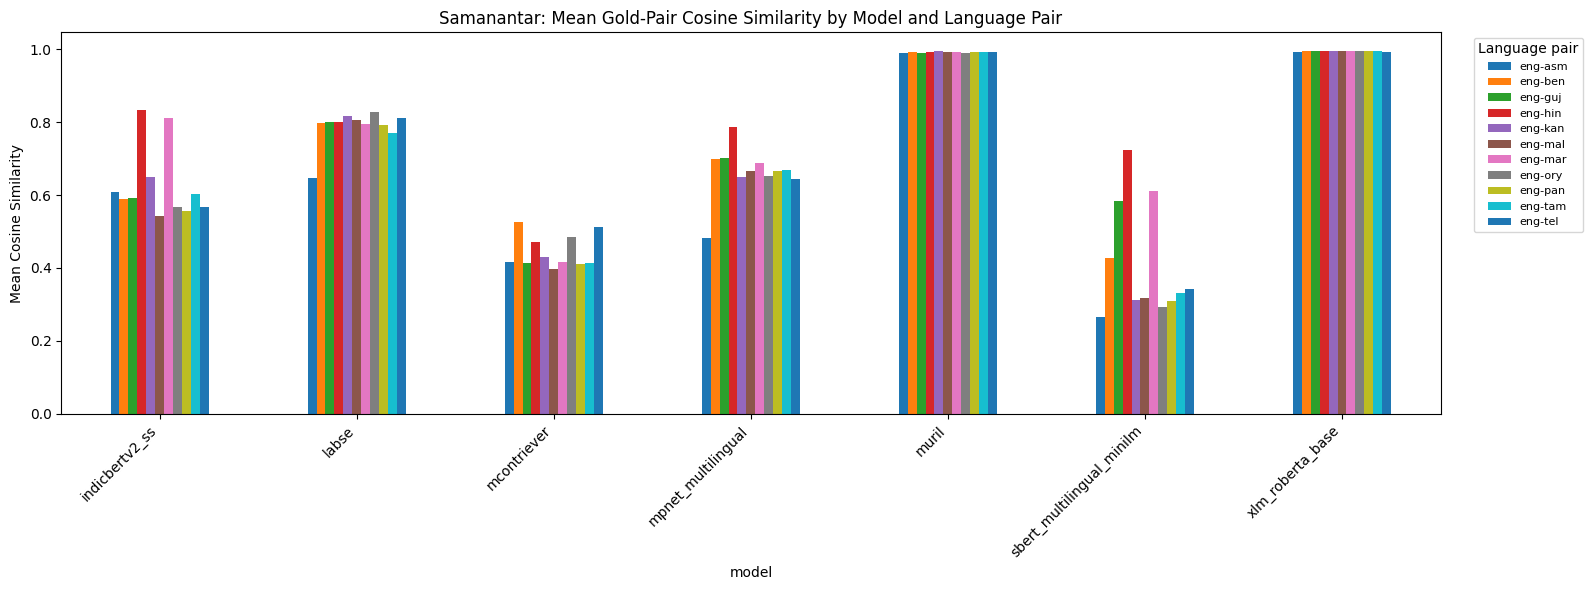

Saved plot: /content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/plots/mean_cosine_by_model_and_pair_samanantar_n2000_l128.png


In [12]:
# Model x language-pair mean cosine chart
pivot = metrics_df.pivot(
    index="model",
    columns="language_pair",
    values="mean_cosine"
)

ax = pivot.plot(kind="bar", figsize=(16, 6))
ax.set_ylabel("Mean Cosine Similarity")
ax.set_title("Samanantar: Mean Gold-Pair Cosine Similarity by Model and Language Pair")
ax.legend(title="Language pair", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = OUTPUT_DIR / "plots" / f"mean_cosine_by_model_and_pair_{RUN_TAG}.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)


## 10. Best and weakest language pairs per model


In [13]:
best_pairs = (
    metrics_df
    .sort_values(["model", "mean_cosine"], ascending=[True, False])
    .groupby("model")
    .head(5)
)

weakest_pairs = (
    metrics_df
    .sort_values(["model", "mean_cosine"], ascending=[True, True])
    .groupby("model")
    .head(5)
)

best_path = OUTPUT_DIR / f"best_pairs_avg_cosine_{RUN_TAG}.csv"
weakest_path = OUTPUT_DIR / f"weakest_pairs_avg_cosine_{RUN_TAG}.csv"

best_pairs.to_csv(best_path, index=False)
weakest_pairs.to_csv(weakest_path, index=False)

print("Best pairs:")
display(best_pairs[["model", "language_pair", "mean_cosine", "median_cosine", "pct_gt_0_80"]])

print("Weakest pairs:")
display(weakest_pairs[["model", "language_pair", "mean_cosine", "median_cosine", "pct_gt_0_80"]])

print("Saved:", best_path)
print("Saved:", weakest_path)


Best pairs:


,model,language_pair,mean_cosine,median_cosine,pct_gt_0_80
47,indicbertv2_ss,eng-hin,0.832758,0.841292,0.7940
50,indicbertv2_ss,eng-mar,0.809994,0.814782,0.6505
48,indicbertv2_ss,eng-kan,0.649287,0.651829,0.0015
44,indicbertv2_ss,eng-asm,0.608048,0.612854,0.0040
53,indicbertv2_ss,eng-tam,0.602659,0.607036,0.0010
7,labse,eng-ory,0.826299,0.834831,0.8640
4,labse,eng-kan,0.816800,0.831797,0.8545
10,labse,eng-tel,0.810918,0.829551,0.8090
5,labse,eng-mal,0.806898,0.828291,0.7960
2,labse,eng-guj,0.801167,0.833569,0.8275


Weakest pairs:


,model,language_pair,mean_cosine,median_cosine,pct_gt_0_80
49,indicbertv2_ss,eng-mal,0.541981,0.539611,0.0005
52,indicbertv2_ss,eng-pan,0.557005,0.552569,0.0035
54,indicbertv2_ss,eng-tel,0.566982,0.565129,0.0030
51,indicbertv2_ss,eng-ory,0.568319,0.571083,0.0015
45,indicbertv2_ss,eng-ben,0.588127,0.591201,0.0000
0,labse,eng-asm,0.645858,0.792538,0.4885
9,labse,eng-tam,0.771223,0.820323,0.6905
8,labse,eng-pan,0.790593,0.825223,0.7100
6,labse,eng-mar,0.793323,0.824162,0.7385
1,labse,eng-ben,0.796062,0.824500,0.7150


Saved: /content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/best_pairs_avg_cosine_samanantar_n2000_l128.csv
Saved: /content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/weakest_pairs_avg_cosine_samanantar_n2000_l128.csv


## 11. Inspect pair-level cosine scores

Use this to see individual sentence-pair scores for one model/language pair.


In [14]:
import glob

score_files = sorted(glob.glob(str(OUTPUT_DIR / "scores" / f"*_{RUN_TAG}_cosine_scores.csv")))

print("Number of score files:", len(score_files))
print("\nFirst 10 score files:")
for p in score_files[:10]:
    print(p)

SCORE_FILE_INDEX = 0

if score_files:
    sample_path = score_files[SCORE_FILE_INDEX]
    print("\nShowing:", sample_path)
    sample_scores = pd.read_csv(sample_path)
    display(sample_scores.head(10))


Number of score files: 77

First 10 score files:
/content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/scores/indicbertv2_ss_eng-asm_samanantar_n2000_l128_cosine_scores.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/scores/indicbertv2_ss_eng-ben_samanantar_n2000_l128_cosine_scores.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/scores/indicbertv2_ss_eng-guj_samanantar_n2000_l128_cosine_scores.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/scores/indicbertv2_ss_eng-hin_samanantar_n2000_l128_cosine_scores.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/scores/indicbertv2_ss_eng-kan_samanantar_n2000_l128_cosine_scores.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/samanantar_avg_cosine/scores/indicbertv2_ss_eng-mal_samanantar_n2000_l128_cosine_scores.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/

,language_pair,source_language,target_language,cosine_similarity,source_text,target_text
0,eng-asm,eng,asm,0.602602,I couldnt think.,ক’বলৈ গলে ভাবিব পৰা নাছিলো।
1,eng-asm,eng,asm,0.623115,The provisions of the Bill will simplify the l...,নতুন এই বিধেয়কত ভাৰতত বাণিজ্যিক জাহাজ চলাচল সম...
2,eng-asm,eng,asm,0.599015,Serial Number,ক্ৰমিক নং
3,eng-asm,eng,asm,0.618385,The situation is very complicated.,অসমত পৰিস্থিতি অতি জটিল হৈছে।
4,eng-asm,eng,asm,0.672611,"When Gods people were in sore straits, however...","কিন্তু তেওঁলোকে যেতিয়া “সঙ্কটৰ সময়ত ” পৰিল, তে..."
5,eng-asm,eng,asm,0.588566,"Mr. Prime Minister, thank you for a very produ...",এক উল্লেখযোগ্য গঠনাত্মক আলোচনাৰ বাবে মই মাননী...
6,eng-asm,eng,asm,0.635198,Jesus first spoke of the privilege they would ...,নিৰন্তৰে যীচুক অনুকৰণ কৰাৰ সৈতে কি সন্মিলিত আছে?
7,eng-asm,eng,asm,0.697031,Couldn't spawn a new process,নতুন প্ৰসেস স্পন কৰতে ব্যৰ্থ
8,eng-asm,eng,asm,0.558555,A militant was also killed in the encounter.,সংঘৰ্ষত এজন সন্ত্ৰাসবাদীও নিহত হৈছে।
9,eng-asm,eng,asm,0.660611,"Secretariat Administration Department, Assam i...",অসম সচিবালয় প্ৰশাসনে প্লাষ্টিক গ্ৰাছ কাৰ্পেট য...


## 12. Interpretation guide

Use these in the report:

- **Mean cosine**: average similarity of correct translation pairs.
- **Median cosine**: typical similarity score.
- **% > 0.80**: fraction of gold pairs that cross a strict similarity threshold.
- This benchmark is different from retrieval Accuracy@1.  
  A pair may have cosine < 0.80 but still be the nearest neighbour in a retrieval benchmark.
